# g-and-k Ablations Notebook

This notebook is the notebook version of the g-and-k ablation plots, adapted to this repo layout. It reads saved ablation `.npz` files from `ablations/`, renders figures inline, and saves the main ablation figures to `figures/`.


In [13]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
ABLATIONS_DIR = ROOT / "ablations"
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

STEP_OUTPUT = FIGURES_DIR / "gk_step_size_ablation.pdf"
DECAY_OUTPUT = FIGURES_DIR / "gk_decay_ablation.pdf"
ALPHA_OUTPUT = FIGURES_DIR / "gk_alpha_ablation.pdf"
MN_OUTPUT = FIGURES_DIR / "gk_mn_theta_error_boxplots.pdf"
LENGTHSCALE_OUTPUT = FIGURES_DIR / "gk_lengthscale_ridge_ablation.pdf"
SUMMARY_OUTPUT = FIGURES_DIR / "gk_ablation_summary.pdf"

FIGSIZE = (6, 4)
SUMMARY_DPI = 150
TITLE_SIZE = 32
LABEL_SIZE = 32
TICK_SIZE = 26
LEGEND_SIZE = 32
MARKER_SIZE = 5
LINE_WIDTH = 2.0
COLORS = {
    "sgd": "#1b9e77",
    "natural": "#7570b3",
    "pgd": "#d95f02",
}
BOX_COLORS = [
    "#4c78a8",
    "#e45756",
    "#72b7b2",
    "#b279a2",
    "#ff9da6",
    "#9d755d",
    "#bab0ab",
]

BASE_PLOT_RC = {
    "axes.grid": True,
    "font.family": "DeJavu Serif",
    "font.serif": ["Times New Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amsfonts, mathrsfs, amssymb}",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "legend.frameon": False,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "lines.linewidth": LINE_WIDTH,
    "lines.markersize": MARKER_SIZE,
    "figure.figsize": FIGSIZE,
    "figure.dpi": 100,
}
LOCAL_PLOT_RC = dict(BASE_PLOT_RC)
plt.rcParams.update(BASE_PLOT_RC)


def _load_npz_dict(npz_path):
    npz_path = Path(npz_path)
    with np.load(npz_path) as data:
        return {key: data[key] for key in data.files}


def _iter_ablation_npz(results_dir):
    for npz_path in sorted(Path(results_dir).rglob("g_n_k_fixed*.npz")):
        if "history" in npz_path.parts:
            continue
        yield npz_path


def _save_figure(fig, output_path=None, **savefig_kwargs):
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, **savefig_kwargs)
    return fig


def _make_single_color_boxplot(ax, series, labels, color, xlabel, ylabel, title=None, logy=True):
    bp = ax.boxplot(series, patch_artist=True, widths=0.6)
    palette = BOX_COLORS
    for idx, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(palette[idx % len(palette)])
        patch.set_alpha(0.8)
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(2.0)
    ax.set_xticks(np.arange(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)
    if logy:
        ax.set_yscale("log")
    return bp


def _theta_error_series_gk(npz_path):
    data = _load_npz_dict(npz_path)
    theta_true = np.asarray(data["theta_true"], dtype=float)
    theta_finals = np.asarray(data["adaptive_thetas"], dtype=float)
    return np.linalg.norm(theta_finals - theta_true[None, :], axis=1)


def make_gk_step_boxplot(results_dir, output_path=None):
    pattern = re.compile(r"g_and_k_step_size_ablation_gamma_pgd0_sweep_(?P<gamma>[^/]+)/")
    collected = {}

    summary_path = results_dir / "g_and_k_step_size_ablation_gamma_pgd0_sweep_summary.npz"
    if summary_path.exists():
        summary = _load_npz_dict(summary_path)
        if "output_paths" in summary and "sweep_values" in summary:
            for gamma, npz_path in zip(summary["sweep_values"], summary["output_paths"]):
                npz_path = Path(npz_path)
                if npz_path.exists():
                    collected[float(gamma)] = _theta_error_series_gk(npz_path)

    for npz_path in _iter_ablation_npz(results_dir):
        match = pattern.search(npz_path.as_posix())
        if match is None:
            continue
        gamma = float(match.group("gamma").replace("p", ".").replace("m", "-"))
        collected[gamma] = _theta_error_series_gk(npz_path)

    ordered = sorted(collected.items(), key=lambda item: item[0])
    labels = [f"{gamma:g}" for gamma, _ in ordered]
    series = [values for _, values in ordered]
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=SUMMARY_DPI)
        _make_single_color_boxplot(ax, series, labels, COLORS["pgd"], "step size," r" $\gamma$", r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$")
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def make_gk_decay_boxplot(results_dir, output_path=None):
    pattern = re.compile(r"g_and_k_decay_ablation_decay_sweep_(?P<decay>[^/]+)/")
    collected = []
    for npz_path in _iter_ablation_npz(results_dir):
        match = pattern.search(npz_path.as_posix())
        if match is None:
            continue
        decay = float(match.group("decay").replace("p", ".").replace("m", "-"))
        data = _load_npz_dict(npz_path)
        collected.append((decay, _theta_error_series_gk(npz_path)))
    collected.sort(key=lambda item: item[0])
    labels = [f"{decay:g}" for decay, _ in collected]
    series = [values for _, values in collected]
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=SUMMARY_DPI)
        _make_single_color_boxplot(ax, series, labels, COLORS["pgd"], "lengthscale decay rate", r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$")
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def make_gk_alpha_boxplot(results_dir, output_path=None):
    pattern = re.compile(r"g_and_k_decay_ablation_ell_decay_alpha_sweep_(?P<alpha>[^/]+)/")
    collected = []
    for npz_path in _iter_ablation_npz(results_dir):
        match = pattern.search(npz_path.as_posix())
        if match is None:
            continue
        alpha = float(match.group("alpha").replace("p", ".").replace("m", "-"))
        collected.append((alpha, _theta_error_series_gk(npz_path)))
    collected.sort(key=lambda item: item[0])
    labels = [f"{alpha:g}" for alpha, _ in collected]
    series = [values for _, values in collected]
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=SUMMARY_DPI)
        _make_single_color_boxplot(ax, series, labels, COLORS["pgd"], "polynomial decay, " r"$\alpha$", r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$")
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def _collect_gk_mn_theta_errors(results_dir):
    pattern = re.compile(r"g_and_k_observation_model_grid_m_(?P<m>[^_]+)_n_(?P<n>[^/]+)/")
    by_mn = {}
    m_values = set()
    n_values = set()
    for npz_path in _iter_ablation_npz(results_dir):
        match = pattern.search(npz_path.as_posix())
        if match is None:
            continue
        m = float(match.group("m").replace("p", ".").replace("m", "-"))
        n = float(match.group("n").replace("p", ".").replace("m", "-"))
        by_mn[(m, n)] = _theta_error_series_gk(npz_path)
        m_values.add(m)
        n_values.add(n)
    return by_mn, sorted(m_values), sorted(n_values)


def make_gk_mn_boxplots(results_dir, output_path=None):
    by_mn, m_values, n_values = _collect_gk_mn_theta_errors(results_dir)
    grouped_by_n = [np.concatenate([by_mn[(m, n)] for m in m_values]) for n in n_values]

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=SUMMARY_DPI)
        _make_single_color_boxplot(
            ax,
            grouped_by_n,
            [f"{n:g}" for n in n_values],
            "#4c78a8",
            r"$n$",
            r"$\Vert\theta_{\mathrm{final}} - \theta_{\mathrm{true}}\Vert_2$",
            # title="PGD grouped by n",
            logy=True,
        )
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def make_gk_ridge_boxplot(results_dir, output_path=None):
    pattern = re.compile(r"g_and_k_regularization_ablation_lambda_scale_sweep_([^/]+)/")
    collected = {}

    summary_path = results_dir / "g_and_k_regularization_ablation_lambda_scale_sweep_summary.npz"
    if summary_path.exists():
        summary = _load_npz_dict(summary_path)
        if "output_paths" in summary and "sweep_values" in summary:
            for lam, npz_path in zip(summary["sweep_values"], summary["output_paths"]):
                npz_path = Path(npz_path)
                if npz_path.exists():
                    collected[float(lam)] = _theta_error_series_gk(npz_path)

    for npz_path in _iter_ablation_npz(results_dir):
        match = pattern.search(npz_path.as_posix())
        if match is None:
            continue
        lam = float(match.group(1).replace("p", ".").replace("m", "-"))
        collected[lam] = _theta_error_series_gk(npz_path)

    ordered = sorted(collected.items(), key=lambda item: item[0])
    labels = [f"{lam:g}" for lam, _ in ordered]
    series = [values for _, values in ordered]
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=SUMMARY_DPI)
        _make_single_color_boxplot(ax, series, labels, COLORS["pgd"], r"ridge constant, $\lambda$", r"$\|	heta_{\mathrm{final}}-	heta_{\mathrm{true}}\|_2$")
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def make_gk_cross_method_comparison(npz_path, output_path=None):
    data = _load_npz_dict(npz_path)
    required = [
        "theta_true",
        "baseline_theta_histories",
        "adaptive_sgd_theta_histories",
        "adaptive_theta_histories",
        "fixed_pgd_theta_histories",
        "baseline_history_steps",
        "adaptive_sgd_history_steps",
        "adaptive_history_steps",
        "fixed_pgd_history_steps",
    ]
    missing = [key for key in required if key not in data]
    if missing:
        raise KeyError("Missing keys for G-and-K cross-method comparison: " + ", ".join(missing))

    theta_true = np.asarray(data["theta_true"], dtype=float)

    def theta_err(histories_key):
        histories = np.asarray(data[histories_key], dtype=float)
        return np.linalg.norm(histories - theta_true[None, None, :], axis=-1)

    baseline_err = theta_err("baseline_theta_histories")
    adaptive_sgd_err = theta_err("adaptive_sgd_theta_histories")
    pgd_err = theta_err("adaptive_theta_histories")
    fixed_pgd_err = theta_err("fixed_pgd_theta_histories")

    baseline_steps = np.asarray(data["baseline_history_steps"], dtype=float) + 1.0
    adaptive_sgd_steps = np.asarray(data["adaptive_sgd_history_steps"], dtype=float) + 1.0
    pgd_steps = np.asarray(data["adaptive_history_steps"], dtype=float) + 1.0
    fixed_pgd_steps = np.asarray(data["fixed_pgd_history_steps"], dtype=float) + 1.0

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(8.2, 5.0), dpi=SUMMARY_DPI)
        ax.plot(baseline_steps, np.mean(baseline_err, axis=0), color=COLORS["sgd"], label="SGD fixed $\ell$")
        ax.plot(adaptive_sgd_steps, np.mean(adaptive_sgd_err, axis=0), color="#4c78a8", label="SGD adaptive $\ell$")
        ax.plot(pgd_steps, np.mean(pgd_err, axis=0), color=COLORS["pgd"], label="PGD adaptive $\ell$")
        ax.plot(fixed_pgd_steps, np.mean(fixed_pgd_err, axis=0), color="#ff9da6", label="PGD fixed $\ell$")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Iteration")
        ax.set_ylabel(r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$")
        ax.set_title("Cross-method comparison")
        ax.legend(loc="best")
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def _collect_gk_series_from_pattern(results_dir, pattern):
    collected = []
    for npz_path in _iter_ablation_npz(results_dir):
        match = pattern.search(npz_path.as_posix())
        if match is None:
            continue
        value = float(match.group(1).replace("p", ".").replace("m", "-"))
        collected.append((value, _theta_error_series_gk(npz_path)))
    collected.sort(key=lambda item: item[0])
    return collected


def _draw_gk_step_boxplot(ax, results_dir):
    pattern = re.compile(r"g_and_k_step_size_ablation_gamma_pgd0_sweep_([^/]+)/")
    collected = {}
    summary_path = results_dir / "g_and_k_step_size_ablation_gamma_pgd0_sweep_summary.npz"
    if summary_path.exists():
        summary = _load_npz_dict(summary_path)
        if "output_paths" in summary and "sweep_values" in summary:
            for gamma, npz_path in zip(summary["sweep_values"], summary["output_paths"]):
                npz_path = Path(npz_path)
                if npz_path.exists():
                    collected[float(gamma)] = _theta_error_series_gk(npz_path)
    for gamma, values in _collect_gk_series_from_pattern(results_dir, pattern):
        collected[gamma] = values
    ordered = sorted(collected.items(), key=lambda item: item[0])
    _make_single_color_boxplot(
        ax,
        [values for _, values in ordered],
        [f"{gamma:g}" for gamma, _ in ordered],
        COLORS["pgd"],
        "step size," r" $\gamma$",
        r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$",
        logy=True,
    )


def _draw_gk_decay_boxplot(ax, results_dir):
    pattern = re.compile(r"g_and_k_decay_ablation_decay_sweep_([^/]+)/")
    collected = _collect_gk_series_from_pattern(results_dir, pattern)
    _make_single_color_boxplot(
        ax,
        [values for _, values in collected],
        [f"{value:g}" for value, _ in collected],
        COLORS["pgd"],
        "exponential decay, " r"$\rho$",
        "",
        logy=True,
    )


def _draw_gk_alpha_boxplot(ax, results_dir):
    pattern = re.compile(r"g_and_k_decay_ablation_ell_decay_alpha_sweep_([^/]+)/")
    collected = _collect_gk_series_from_pattern(results_dir, pattern)
    _make_single_color_boxplot(
        ax,
        [values for _, values in collected],
        [f"{value:g}" for value, _ in collected],
        COLORS["pgd"],
        "polynomial decay, " r"$\alpha$",
        "",
        logy=True,
    )


def _draw_gk_mn_boxplot(ax, results_dir):
    by_mn, m_values, n_values = _collect_gk_mn_theta_errors(results_dir)
    grouped_by_n = [np.concatenate([by_mn[(m, n)] for m in m_values]) for n in n_values]
    _make_single_color_boxplot(
        ax,
        grouped_by_n,
        [f"{n:g}" for n in n_values],
        "#4c78a8",
        r"$n$",
        "",
        logy=True,
    )


def _draw_gk_ridge_boxplot(ax, results_dir):
    pattern = re.compile(r"g_and_k_regularization_ablation_lambda_scale_sweep_([^/]+)/")
    collected = {}
    summary_path = results_dir / "g_and_k_regularization_ablation_lambda_scale_sweep_summary.npz"
    if summary_path.exists():
        summary = _load_npz_dict(summary_path)
        if "output_paths" in summary and "sweep_values" in summary:
            for lam, npz_path in zip(summary["sweep_values"], summary["output_paths"]):
                npz_path = Path(npz_path)
                if npz_path.exists():
                    collected[float(lam)] = _theta_error_series_gk(npz_path)
    for npz_path in _iter_ablation_npz(results_dir):
        match = pattern.search(npz_path.as_posix())
        if match is None:
            continue
        lam = float(match.group(1).replace("p", ".").replace("m", "-"))
        collected[lam] = _theta_error_series_gk(npz_path)
    ordered = sorted(collected.items(), key=lambda item: item[0])
    if not ordered:
        raise FileNotFoundError(f"No G-and-K ridge ablation .npz files found in {results_dir}")
    _make_single_color_boxplot(ax, [values for _, values in ordered], [f"{lam:g}" for lam, _ in ordered], COLORS["pgd"], r"ridge constant, $\lambda$", r"")


def make_gk_ablation_summary(gk_step_dir, gk_decay_dir, gk_alpha_dir, gk_mn_dir, gk_ridge_dir, output_path=None, figsize=(30, 5), dpi=150):
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, axes = plt.subplots(1, 5, figsize=figsize, dpi=dpi, gridspec_kw={"width_ratios": [1.0, 1.0, 1.0, 1.0, 1.18]})
        _draw_gk_step_boxplot(axes[0], gk_step_dir)
        _draw_gk_decay_boxplot(axes[1], gk_decay_dir)
        _draw_gk_alpha_boxplot(axes[2], gk_alpha_dir)
        _draw_gk_mn_boxplot(axes[3], gk_mn_dir)
        _draw_gk_ridge_boxplot(axes[4], gk_ridge_dir)
        fig.suptitle("G-and-k distribution", fontsize=TITLE_SIZE)
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


## Local file setup

These defaults match the saved g-and-k ablation files that currently exist in this repo.


In [14]:
gk_step_dir = ABLATIONS_DIR / "gk_gamma"
gk_decay_dir = ABLATIONS_DIR / "gk_decay"
gk_alpha_dir = ABLATIONS_DIR / "gk_alpha"
gk_mn_dir = ABLATIONS_DIR / "gk_mn_grid"
gk_ridge_dir = ABLATIONS_DIR / "gk_ridge"
gk_compare_npz = ROOT / "g_n_k_fixed600_theta0_2p000_2p000_1p500_m0p300.npz"

{
    "gk_step_dir": gk_step_dir,
    "gk_decay_dir": gk_decay_dir,
    "gk_alpha_dir": gk_alpha_dir,
    "gk_mn_dir": gk_mn_dir,
    "gk_ridge_dir": gk_ridge_dir,
    "gk_compare_npz": gk_compare_npz,
    "outputs": [STEP_OUTPUT, DECAY_OUTPUT, ALPHA_OUTPUT, MN_OUTPUT, LENGTHSCALE_OUTPUT],
}


{'gk_step_dir': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_gamma'),
 'gk_decay_dir': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_decay'),
 'gk_alpha_dir': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_alpha'),
 'gk_mn_dir': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_mn_grid'),
 'gk_ridge_dir': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_ridge'),
 'gk_compare_npz': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/g_n_k_fixed600_theta0_2p000_2p000_1p500_m0p300.npz'),
 'outputs': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_step_size_ablation.pdf'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_decay_ablation.pdf'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_alpha_ablation.pdf'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_mn_theta_error_boxplots.pdf'),
  PosixPath('/Users/sophiakang/Documents

In [15]:
available_inputs = {
    "gk_step_files": list(_iter_ablation_npz(gk_step_dir)),
    "gk_decay_files": list(_iter_ablation_npz(gk_decay_dir)),
    "gk_alpha_files": list(_iter_ablation_npz(gk_alpha_dir)),
    "gk_mn_files": list(_iter_ablation_npz(gk_mn_dir)),
    "gk_ridge_files": list(_iter_ablation_npz(gk_ridge_dir)),
    "gk_ridge_present": any(_iter_ablation_npz(gk_ridge_dir)),
    "gk_compare_npz": gk_compare_npz.exists(),
}
available_inputs


{'gk_step_files': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_gamma/g_and_k_step_size_ablation_gamma_pgd0_sweep_0p03/g_n_k_fixed600_theta0_3p500_2p000_0p600_m0p800.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_gamma/g_and_k_step_size_ablation_gamma_pgd0_sweep_0p1/g_n_k_fixed600_theta0_3p500_2p000_0p600_m0p800.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_gamma/g_and_k_step_size_ablation_gamma_pgd0_sweep_0p3/g_n_k_fixed600_theta0_3p500_2p000_0p600_m0p800.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_gamma/g_and_k_step_size_ablation_gamma_pgd0_sweep_1/g_n_k_fixed600_theta0_3p500_2p000_0p600_m0p800.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_gamma/g_and_k_step_size_ablation_gamma_pgd0_sweep_10/g_n_k_fixed600_theta0_3p500_2p000_0p600_m0p800.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_gamma/g_and_k_step_size_ablation_gamm

Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_ablation_summary.pdf


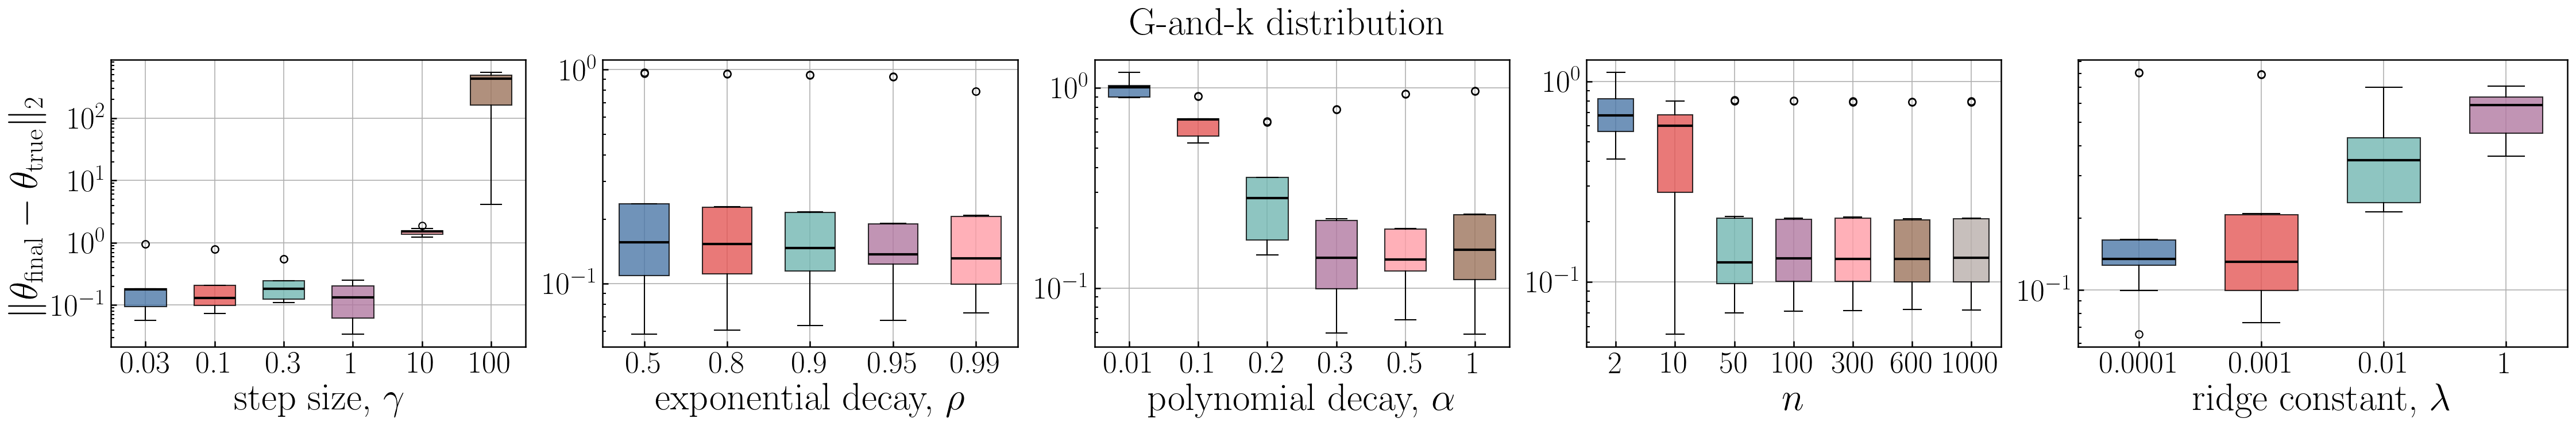

In [16]:
required_inputs = [
    *list(_iter_ablation_npz(gk_step_dir)),
    *list(_iter_ablation_npz(gk_decay_dir)),
    *list(_iter_ablation_npz(gk_alpha_dir)),
    *list(_iter_ablation_npz(gk_mn_dir)),
    *list(_iter_ablation_npz(gk_ridge_dir)),
]
missing_inputs = [path for path in required_inputs if not Path(path).exists()]
if not any(_iter_ablation_npz(gk_ridge_dir)):
    missing_inputs.append(gk_ridge_dir)

if not missing_inputs:
    fig = make_gk_ablation_summary(
        gk_step_dir=gk_step_dir,
        gk_decay_dir=gk_decay_dir,
        gk_alpha_dir=gk_alpha_dir,
        gk_mn_dir=gk_mn_dir,
        gk_ridge_dir=gk_ridge_dir,
        output_path=None,
        figsize=(30, 5),
        dpi=SUMMARY_DPI,
    )
    fig.savefig(SUMMARY_OUTPUT, bbox_inches="tight")
    print(f"Saved figure to {SUMMARY_OUTPUT}")
    display(fig)
else:
    print(
        f"Figure not rendered because {len(missing_inputs)} source input(s) are missing: "
        + ", ".join(str(path) for path in missing_inputs)
    )
 